<a href="https://colab.research.google.com/github/T31SHA/Nairobi_Flood_Guard-AI/blob/ft-Carl/Logistic_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importing relevant libraries
import geopandas as gpd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, auc, roc_curve
import matplotlib.pyplot as plt
import pickle

# Load the feature matrix
wards = gpd.read_file("../../Data/floods.gpkg")

# Drop geometry and metadata for modelling — keep only numeric features and target
feature_cols = [
    'pop2009',
    'rain_cumulative_mm',
    'rain_max_daily_mm',
    'rain_preflood_7d_mm',
    'elevation_mean_m',
    'elevation_min_m',
    'slope_mean_deg'
]

X = wards[feature_cols]
y = wards['flooded']

print(f"Feature matrix shape : {X.shape}")
print(f"Class distribution   :\n{y.value_counts(normalize=True)}")
print(f"\nMissing values:\n{X.isnull().sum()}")

Feature matrix shape : (1450, 7)
Class distribution   :
flooded
0    0.788276
1    0.211724
Name: proportion, dtype: float64

Missing values:
pop2009                0
rain_cumulative_mm     0
rain_max_daily_mm      0
rain_preflood_7d_mm    0
elevation_mean_m       0
elevation_min_m        0
slope_mean_deg         0
dtype: int64


In [2]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1160, 7)
Testing set shape: (290, 7)


In [3]:
from sklearn.linear_model import LogisticRegression
# Create logistic regression model
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Train model
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [4]:
# Predictions
y_pred = log_reg.predict(X_test)

# Probabilities for ROC curve
y_proba = log_reg.predict_proba(X_test)[:, 1]

In [5]:
# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.79      0.85       229
           1       0.48      0.70      0.57        61

    accuracy                           0.78       290
   macro avg       0.69      0.75      0.71       290
weighted avg       0.82      0.78      0.79       290



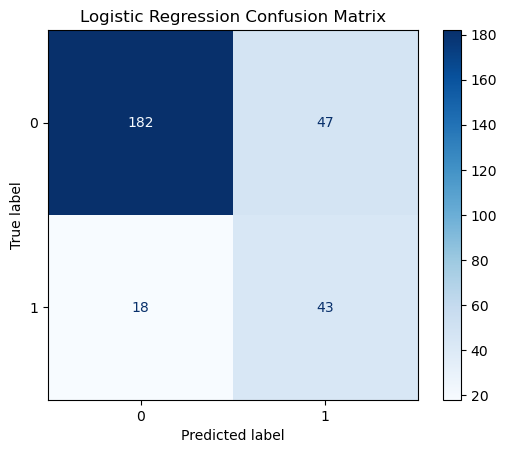

In [6]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=log_reg.classes_
)

disp.plot(cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.show()

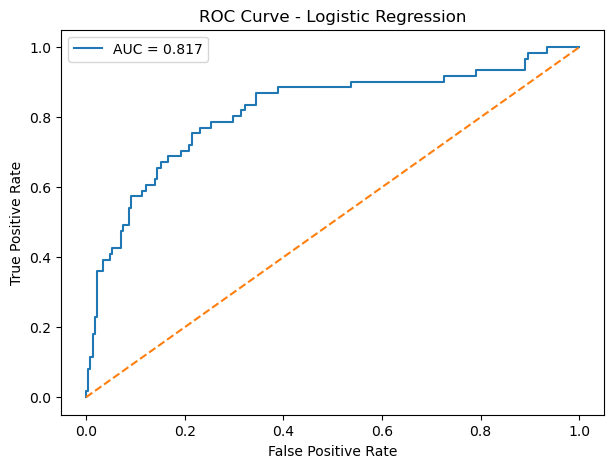

ROC-AUC Score: 0.8165938864628821


In [7]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

The Logistic Regression model achieved an ROC-AUC score of 0.81, indicating good ability to distinguish between flooded and non-flooded wards.

The model achieved higher performance for the non-flooded class than the flooded class, which is expected because the dataset is imbalanced. However, the recall score of 0.70 for flooded wards suggests that the model is able to correctly identify most flood-prone wards.

This is important for disaster preparedness because failing to identify a flooded ward may have more severe consequences than generating a false warning.

Although precision for flooded wards remains moderate, the model provides a useful baseline for flood risk prediction using rainfall and terrain-related features.

Saving the model:

In [8]:
with open('../best_log_reg_model.pkl', 'wb') as f:
    pickle.dump(log_reg, f)

print("Model saved successfully")

Model saved successfully
